# End-to-End Fault Detection and Classification

This notebook combines the Mahalanobis gatekeeper from `detection2.ipynb` with the 1D CNN classifier from `new2.ipynb`.

Workflow:
1. Split every folder into train, validation, and test at the file level.
2. Train the fault detector on every known operating condition, defined here as every folder except `unknown/`.
3. Train the 1D CNN on the same known classes only.
4. Evaluate the cascaded system where the detector short-circuits predicted unknown samples before the classifier runs.
        

In [74]:
from __future__ import annotations

import copy
import os
import random
import sys
from collections import Counter, OrderedDict
from pathlib import Path

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "experiment").exists() and (candidate / "fdd_system").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from experiment.utils import prepare_training_data
from fdd_system.ML.common.classification.preprocessor import RMSNormalization
from fdd_system.ML.common.config.data import RawAccWindow
from fdd_system.ML.common.config.operating_types import OperatingCondition

SEED = 42
DETERMINISTIC = False

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if DETERMINISTIC:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
else:
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Repo root:", ROOT)
print("Device:", DEVICE)
        

Repo root: /home/btanady/fourth_year/cpen491
Device: cuda


## Data split

The split happens once, before any windowing or preprocessing, so train/validation/test windows never overlap through the same source file.
        

In [75]:
DATASET_NAME = "data_14"
DATA_PATH = ROOT / "experiment" / DATASET_NAME
UNKNOWN_DIRNAME = "unknown"

REMOVE_FIRST_SECOND = 2.0
COLS = ["X", "Y", "Z"]

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2
if abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) > 1e-6:
    raise ValueError("TRAIN_RATIO + VAL_RATIO + TEST_RATIO must sum to 1.0")

TRIPLET_BATCH_SIZE = 512
TRIPLET_EPOCHS = 40
TRIPLET_MARGIN = 0.5
WEIBULL_Q = 0.98

CNN_BATCH_SIZE = 64
CNN_EPOCHS = 40
CNN_EARLY_STOP_PATIENCE = 8
NOISE_STD_G = 0.002
NOISE_COPIES = 0

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

KNOWN_FOLDER_TO_LABEL = OrderedDict([
    ("normal", OperatingCondition.NORMAL.value),
    ("blocked", OperatingCondition.BLOCKED_AIRFLOW.value),
    ("interfere", OperatingCondition.BLADE_ISSUE.value),
    ("power_issue", OperatingCondition.POWER_ISSUE.value),
])
UNKNOWN_LABEL = max(condition.value for condition in OperatingCondition) + 1
LABEL_TO_NAME = {
    OperatingCondition.NORMAL.value: "NORMAL",
    OperatingCondition.BLOCKED_AIRFLOW.value: "BLOCKED",
    OperatingCondition.BLADE_ISSUE.value: "INTERFERE",
    OperatingCondition.POWER_ISSUE.value: "POWER_ISSUE",
    UNKNOWN_LABEL: "UNKNOWN",
}

available_folders = sorted(path.name.lower() for path in DATA_PATH.iterdir() if path.is_dir())
unsupported_folders = sorted(set(available_folders) - (set(KNOWN_FOLDER_TO_LABEL) | {UNKNOWN_DIRNAME}))
if unsupported_folders:
    raise ValueError(f"Unsupported folders under {DATA_PATH}: {unsupported_folders}")

known_folders = [folder for folder in KNOWN_FOLDER_TO_LABEL if folder in available_folders]
if not known_folders:
    raise ValueError(f"No known folders found under {DATA_PATH}")

has_unknown = UNKNOWN_DIRNAME in available_folders


def list_csvs(folder_name: str) -> list[str]:
    return sorted(str(path) for path in (DATA_PATH / folder_name).glob("*.csv"))


def split_files(files: list[str], seed: int = SEED) -> dict[str, list[str]]:
    files = list(files)
    if not files:
        return {"train": [], "val": [], "test": []}

    rng = np.random.default_rng(seed)
    files = [files[i] for i in rng.permutation(len(files))]
    n_files = len(files)

    if n_files == 1:
        return {"train": files, "val": [], "test": []}
    if n_files == 2:
        return {"train": files[:1], "val": [], "test": files[1:]}

    n_test = max(1, int(round(n_files * TEST_RATIO)))
    n_val = max(1, int(round(n_files * VAL_RATIO))) if VAL_RATIO > 0 else 0

    while n_files - n_test - n_val < 1:
        if n_val > 1:
            n_val -= 1
        else:
            n_test -= 1

    n_train = n_files - n_val - n_test
    return {
        "train": files[:n_train],
        "val": files[n_train:n_train + n_val],
        "test": files[n_train + n_val:],
    }


split_index: OrderedDict[str, dict[str, list[str]]] = OrderedDict()
folders_for_split = known_folders + ([UNKNOWN_DIRNAME] if has_unknown else [])
for offset, folder_name in enumerate(folders_for_split):
    split_index[folder_name] = split_files(list_csvs(folder_name), seed=SEED + offset)

split_summary = pd.DataFrame(
    [
        {
            "folder": folder_name,
            "train_files": len(parts["train"]),
            "val_files": len(parts["val"]),
            "test_files": len(parts["test"]),
            "total_files": sum(len(parts[split]) for split in ["train", "val", "test"]),
        }
        for folder_name, parts in split_index.items()
    ]
)
print(split_summary.to_string(index=False))

if not has_unknown:
    print()
print("No unknown/ folder found. UNKNOWN will still appear in the final confusion matrix with zero support.")


def file_map_for(split_name: str, include_unknown: bool = False) -> OrderedDict[int, list[str]]:
    mapping: OrderedDict[int, list[str]] = OrderedDict()
    for folder_name in known_folders:
        mapping[KNOWN_FOLDER_TO_LABEL[folder_name]] = split_index[folder_name][split_name]
    if include_unknown:
        mapping[UNKNOWN_LABEL] = split_index.get(UNKNOWN_DIRNAME, {}).get(split_name, [])
    return mapping


known_train_files = file_map_for("train")
known_val_files = file_map_for("val")
known_test_files = file_map_for("test")
full_test_files = file_map_for("test", include_unknown=True)

print()
print("Known class order:", [LABEL_TO_NAME[KNOWN_FOLDER_TO_LABEL[name]] for name in known_folders])
        

   folder  train_files  val_files  test_files  total_files
   normal            5          1           1            7
  blocked            5          1           1            7
interfere            5          1           1            7
  unknown            5          1           1            7
No unknown/ folder found. UNKNOWN will still appear in the final confusion matrix with zero support.

Known class order: ['NORMAL', 'BLOCKED', 'INTERFERE']


In [76]:
def prepare_windows_for_map(file_map: OrderedDict[int, list[str]], shuffle: bool) -> list[RawAccWindow]:
    windows = prepare_training_data(
        file_map,
        shuffle=shuffle,
        col_names=COLS,
        remove_first_second=REMOVE_FIRST_SECOND,
    )
    return RMSNormalization().preprocess(windows)


def stack_windows(windows: list[RawAccWindow], target_len: int | None = None):
    if not windows:
        raise ValueError("No windows found for the requested split.")

    if target_len is None:
        target_len = min(
            min(len(window.acc_x), len(window.acc_y), len(window.acc_z))
            for window in windows
        )

    X = np.empty((len(windows), 3, target_len), dtype=np.float32)
    y = np.empty((len(windows),), dtype=np.int64)

    for idx, window in enumerate(windows):
        X[idx, 0] = np.asarray(window.acc_x, dtype=np.float32)[:target_len]
        X[idx, 1] = np.asarray(window.acc_y, dtype=np.float32)[:target_len]
        X[idx, 2] = np.asarray(window.acc_z, dtype=np.float32)[:target_len]
        y[idx] = int(window.label)

    return X, y, target_len


def named_label_counts(labels: np.ndarray) -> dict[str, int]:
    counts = Counter(int(label) for label in labels.tolist())
    return {LABEL_TO_NAME.get(label, str(label)): counts[label] for label in sorted(counts)}


def with_noise(window: RawAccWindow, noise_std: float) -> RawAccWindow:
    return RawAccWindow(
        acc_x=window.acc_x + np.random.normal(0, noise_std, size=window.acc_x.shape),
        acc_y=window.acc_y + np.random.normal(0, noise_std, size=window.acc_y.shape),
        acc_z=window.acc_z + np.random.normal(0, noise_std, size=window.acc_z.shape),
        label=window.label,
        device_id=window.device_id,
        timestamps=window.timestamps,
        sampling_rate_hz=window.sampling_rate_hz,
        acc_mag=window.acc_mag,
    )


known_train_pre = prepare_windows_for_map(known_train_files, shuffle=True)
known_val_pre = prepare_windows_for_map(known_val_files, shuffle=False)
known_test_pre = prepare_windows_for_map(known_test_files, shuffle=False)
full_test_pre = prepare_windows_for_map(full_test_files, shuffle=False)

print("Window counts after RMS normalization:")
for split_name, windows in [
    ("known_train", known_train_pre),
    ("known_val", known_val_pre),
    ("known_test", known_test_pre),
    ("full_test", full_test_pre),
]:
    labels = np.array([int(window.label) for window in windows], dtype=np.int64)
    print(f"  {split_name:11s}: {len(windows):4d} windows -> {named_label_counts(labels)}")

classifier_train_pre = list(known_train_pre)
if NOISE_COPIES > 0 and NOISE_STD_G > 0:
    noisy_windows = []
    for _ in range(NOISE_COPIES):
        noisy_windows.extend(with_noise(window, NOISE_STD_G) for window in known_train_pre)
    classifier_train_pre = classifier_train_pre + noisy_windows
    print(f"Added {len(noisy_windows)} noisy windows to the classifier training split.")
else:
    print("Noise augmentation disabled for the CNN stage.")

X_train_known_raw, y_train_known_raw, target_len = stack_windows(known_train_pre)
X_val_known_raw, y_val_known_raw, _ = stack_windows(known_val_pre, target_len=target_len)
X_known_test_raw, y_known_test_raw, _ = stack_windows(known_test_pre, target_len=target_len)
X_full_test_raw, y_full_test_raw, _ = stack_windows(full_test_pre, target_len=target_len)
X_train_classifier_raw, y_train_classifier_raw, _ = stack_windows(classifier_train_pre, target_len=target_len)

mean = X_train_known_raw.mean(axis=(0, 2), keepdims=True)
std = X_train_known_raw.std(axis=(0, 2), keepdims=True) + 1e-6

X_train_known = (X_train_known_raw - mean) / std
X_val_known = (X_val_known_raw - mean) / std
X_known_test = (X_known_test_raw - mean) / std
X_full_test = (X_full_test_raw - mean) / std
X_train_classifier = (X_train_classifier_raw - mean) / std

known_labels = sorted({*y_train_known_raw.tolist(), *y_val_known_raw.tolist(), *y_known_test_raw.tolist()})
classifier_label_to_idx = {label: idx for idx, label in enumerate(known_labels)}
classifier_idx_to_label = {idx: label for label, idx in classifier_label_to_idx.items()}

y_train_classifier = np.array([classifier_label_to_idx[int(label)] for label in y_train_classifier_raw], dtype=np.int64)
y_val_classifier = np.array([classifier_label_to_idx[int(label)] for label in y_val_known_raw], dtype=np.int64)
y_known_test_classifier = np.array([classifier_label_to_idx[int(label)] for label in y_known_test_raw], dtype=np.int64)

print()
print("Tensor shapes:")
print("  detector train:", X_train_known.shape)
print("  detector val:  ", X_val_known.shape)
print("  known test:    ", X_known_test.shape)
print("  full test:     ", X_full_test.shape)
print("  classifier train labels:", named_label_counts(y_train_classifier_raw))
        

Window counts after RMS normalization:
  known_train:  615 windows -> {'NORMAL': 205, 'BLOCKED': 205, 'INTERFERE': 205}
  known_val  :  123 windows -> {'NORMAL': 41, 'BLOCKED': 41, 'INTERFERE': 41}
  known_test :  123 windows -> {'NORMAL': 41, 'BLOCKED': 41, 'INTERFERE': 41}
  full_test  :  164 windows -> {'NORMAL': 41, 'BLOCKED': 41, 'INTERFERE': 41, 'UNKNOWN': 41}
Noise augmentation disabled for the CNN stage.

Tensor shapes:
  detector train: (615, 3, 1000)
  detector val:   (123, 3, 1000)
  known test:     (123, 3, 1000)
  full test:      (164, 3, 1000)
  classifier train labels: {'NORMAL': 205, 'BLOCKED': 205, 'INTERFERE': 205}


## Section 1: Fault detection

Train the Mahalanobis gatekeeper on every known operating condition. Unknown data is excluded from training and only appears in the held-out evaluation split.
        

In [77]:
def plot_confusion(y_true, y_pred, labels, display_labels, title, figsize=(4, 4), values_format="d"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=figsize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, cmap="Blues", values_format=values_format, colorbar=False)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.tight_layout()
    plt.show()
    return cm


def plot_true_label_binary_confusion(
    y_true_labels,
    y_pred_binary,
    true_labels,
    true_display_labels,
    title,
    pred_display_labels=("known", "unknown"),
    figsize=(4.8, 4.2),
):
    cm = np.zeros((len(true_labels), len(pred_display_labels)), dtype=int)
    for row, true_label in enumerate(true_labels):
        mask = y_true_labels == true_label
        if not np.any(mask):
            continue
        for col, pred_label in enumerate(range(len(pred_display_labels))):
            cm[row, col] = int(np.sum(mask & (y_pred_binary == pred_label)))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(pred_display_labels)))
    ax.set_xticklabels(pred_display_labels)
    ax.set_yticks(range(len(true_display_labels)))
    ax.set_yticklabels(true_display_labels)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    threshold = cm.max() / 2.0 if cm.size else 0.0
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            color = "white" if cm[row, col] > threshold else "black"
            ax.text(col, row, str(cm[row, col]), ha="center", va="center", color=color)

    plt.tight_layout()
    plt.show()
    return cm


def batch_hard_triplet_loss(embeddings, labels, margin=0.5):
    if embeddings.size(0) < 2:
        return torch.tensor(0.0, device=embeddings.device)

    distances = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.view(-1, 1)
    positive_mask = labels == labels.T
    negative_mask = labels != labels.T
    positive_mask.fill_diagonal_(False)

    positive_distances = distances.clone()
    positive_distances[~positive_mask] = -1.0
    hardest_positive, _ = positive_distances.max(dim=1)

    negative_distances = distances.clone()
    negative_distances[~negative_mask] = float("inf")
    hardest_negative, _ = negative_distances.min(dim=1)

    valid = (hardest_positive >= 0) & torch.isfinite(hardest_negative)
    if valid.sum() == 0:
        return torch.tensor(0.0, device=embeddings.device)

    return F.relu(hardest_positive[valid] - hardest_negative[valid] + margin).mean()


class TripletCNN(nn.Module):
    def __init__(self, in_channels=3, out_dim=16):
        super().__init__()
        self.time_branch = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.freq_branch = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=3, dilation=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, dilation=4, padding=4),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, dilation=8, padding=8),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, out_dim),
        )

    def forward(self, x):
        time_emb = self.time_branch(x)
        freq = torch.abs(torch.fft.rfft(x, dim=2))
        freq_emb = self.freq_branch(freq)
        embedding = torch.cat([time_emb, freq_emb], dim=1)
        return self.proj(embedding)


def train_triplet_encoder_raw(x_train, y_train, emb_dim=16, epochs=40, batch_size=512, lr=1e-3, margin=0.5):
    model = TripletCNN(in_channels=x_train.shape[1], out_dim=emb_dim).to(DEVICE)
    dataset = TensorDataset(torch.from_numpy(x_train).float(), torch.from_numpy(y_train).long())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            embeddings = model(xb)
            loss = batch_hard_triplet_loss(embeddings, yb, margin=margin)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * yb.size(0)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            avg_loss = total_loss / max(len(loader.dataset), 1)
            print(f"triplet epoch={epoch:02d} loss={avg_loss:.4f}")

    return model


@torch.no_grad()
def encode_embeddings_raw(model, x_np, batch_size=512):
    model.eval()
    embeddings = []
    for start in range(0, len(x_np), batch_size):
        xb = torch.from_numpy(x_np[start:start + batch_size]).float().to(DEVICE)
        embeddings.append(model(xb).cpu().numpy())
    return np.vstack(embeddings)


def class_stats(embeddings, labels, reg=1e-3):
    stats = {}
    for label in sorted(set(labels.tolist())):
        class_embeddings = embeddings[labels == label]
        if len(class_embeddings) < 2:
            continue
        mu = class_embeddings.mean(axis=0)
        cov = np.cov(class_embeddings, rowvar=False)
        cov = cov + reg * np.eye(cov.shape[0])
        stats[int(label)] = (mu, np.linalg.pinv(cov))
    return stats


def mahalanobis_distance_matrix(embeddings, stats):
    labels = sorted(stats.keys())
    if not labels:
        return [], np.empty((len(embeddings), 0), dtype=np.float32)

    distances = np.zeros((len(embeddings), len(labels)), dtype=np.float32)
    for column, label in enumerate(labels):
        mu, inv_cov = stats[label]
        diff = embeddings - mu
        dist_sq = np.einsum("bi,ij,bj->b", diff, inv_cov, diff)
        distances[:, column] = np.sqrt(np.maximum(dist_sq, 0.0))
    return labels, distances


def mahalanobis_scores(embeddings, stats):
    labels, distances = mahalanobis_distance_matrix(embeddings, stats)
    if not labels:
        return np.full(len(embeddings), np.inf), np.full(len(embeddings), -1, dtype=int)

    min_index = np.argmin(distances, axis=1)
    min_distance = distances[np.arange(len(embeddings)), min_index]
    nearest_label = np.array([labels[idx] for idx in min_index], dtype=np.int64)
    return min_distance, nearest_label


def mahalanobis_distance_to_label(embeddings, stats, target_label):
    labels, distances = mahalanobis_distance_matrix(embeddings, stats)
    if target_label not in labels:
        return np.full(len(embeddings), np.inf, dtype=np.float32)
    label_index = labels.index(int(target_label))
    return distances[:, label_index]


def weibull_fit(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    if len(values) < 2:
        return 1.0, float(np.max(values)) if len(values) else 1.0

    values = np.sort(values)
    probs = (np.arange(1, len(values) + 1) - 0.3) / (len(values) + 0.4)
    y = np.log(-np.log(1.0 - probs))
    x = np.log(values)
    slope, intercept = np.polyfit(x, y, 1)
    k = max(float(slope), 1e-6)
    lam = float(np.exp(-intercept / k))
    return k, lam


def weibull_quantile(k, lam, quantile):
    quantile = min(max(quantile, 1e-6), 1.0 - 1e-6)
    return float(lam * (-np.log(1.0 - quantile)) ** (1.0 / k))


def fit_mahalanobis_gatekeeper(x_train, y_train, x_val, y_val, *, emb_dim=16):
    encoder = train_triplet_encoder_raw(
        x_train,
        y_train,
        emb_dim=emb_dim,
        epochs=TRIPLET_EPOCHS,
        batch_size=TRIPLET_BATCH_SIZE,
        margin=TRIPLET_MARGIN,
    )
    z_train = encode_embeddings_raw(encoder, x_train)
    z_val = encode_embeddings_raw(encoder, x_val)

    scaler = StandardScaler().fit(z_train)
    z_train_scaled = scaler.transform(z_train)
    z_val_scaled = scaler.transform(z_val)

    stats = class_stats(z_train_scaled, y_train)
    all_val_distances = []
    threshold_details = {}

    for label in sorted(stats):
        label_mask = y_val == label
        if not label_mask.any():
            continue

        own_class_distances = mahalanobis_distance_to_label(z_val_scaled[label_mask], stats, label)
        own_class_distances = own_class_distances[np.isfinite(own_class_distances)]
        if len(own_class_distances) == 0:
            continue

        all_val_distances.append(own_class_distances)
        k, lam = weibull_fit(own_class_distances)
        threshold_details[int(label)] = {
            "threshold": weibull_quantile(k, lam, WEIBULL_Q),
            "weibull_k": k,
            "weibull_lambda": lam,
            "num_val_samples": int(len(own_class_distances)),
            "median_distance": float(np.median(own_class_distances)),
            "max_distance": float(np.max(own_class_distances)),
            "used_fallback": False,
        }

    if all_val_distances:
        fallback_distances = np.concatenate(all_val_distances)
    else:
        fallback_distances, _ = mahalanobis_scores(z_val_scaled, stats)
        fallback_distances = fallback_distances[np.isfinite(fallback_distances)]

    fallback_k, fallback_lam = weibull_fit(fallback_distances)
    fallback_threshold = weibull_quantile(fallback_k, fallback_lam, WEIBULL_Q)

    for label in sorted(stats):
        if label in threshold_details:
            continue
        threshold_details[int(label)] = {
            "threshold": fallback_threshold,
            "weibull_k": fallback_k,
            "weibull_lambda": fallback_lam,
            "num_val_samples": 0,
            "median_distance": float(np.median(fallback_distances)) if len(fallback_distances) else float("nan"),
            "max_distance": float(np.max(fallback_distances)) if len(fallback_distances) else float("nan"),
            "used_fallback": True,
        }

    per_class_thresholds = {label: details["threshold"] for label, details in threshold_details.items()}

    return {
        "encoder": encoder,
        "scaler": scaler,
        "stats": stats,
        "per_class_thresholds": per_class_thresholds,
        "threshold_details": threshold_details,
        "fallback_threshold": fallback_threshold,
        "fallback_weibull_k": fallback_k,
        "fallback_weibull_lambda": fallback_lam,
    }


def predict_gatekeeper(bundle, x_np):
    embeddings = encode_embeddings_raw(bundle["encoder"], x_np)
    embeddings_scaled = bundle["scaler"].transform(embeddings)
    min_distance, nearest_label = mahalanobis_scores(embeddings_scaled, bundle["stats"])
    applied_threshold = np.array(
        [bundle["per_class_thresholds"].get(int(label), bundle["fallback_threshold"]) for label in nearest_label],
        dtype=np.float32,
    )
    is_unknown = (min_distance > applied_threshold).astype(np.int64)
    return {
        "embeddings": embeddings_scaled,
        "distance": min_distance,
        "nearest_label": nearest_label,
        "applied_threshold": applied_threshold,
        "is_unknown": is_unknown,
    }


triplet epoch=01 loss=0.6529
triplet epoch=10 loss=0.4114
triplet epoch=20 loss=0.3629
triplet epoch=30 loss=0.3375
triplet epoch=40 loss=0.3223


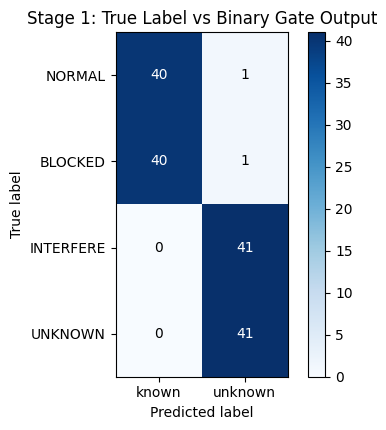

 accuracy  known_false_positive_rate  unknown_recall  fallback_threshold
 0.737805                   0.349593             1.0            4.802973

Per-class Mahalanobis thresholds:
 label class_name  threshold  val_samples  median_distance  max_distance  used_fallback
     0     NORMAL   4.550281           41         3.275740      5.905537          False
     1    BLOCKED   4.992319           41         3.995426      5.232734          False
     2  INTERFERE   4.381662           41         3.276942      4.251936          False

Stage 1 confusion matrix with true labels on rows and binary gate output on columns:
           known  unknown
NORMAL        40        1
BLOCKED       40        1
INTERFERE      0       41
UNKNOWN        0       41

              precision    recall  f1-score   support

       known       1.00      0.65      0.79       123
     unknown       0.49      1.00      0.66        41

    accuracy                           0.74       164
   macro avg       0.74      0.8

In [78]:
gatekeeper = fit_mahalanobis_gatekeeper(X_train_known, y_train_known_raw, X_val_known, y_val_known_raw)
stage1_test = predict_gatekeeper(gatekeeper, X_full_test)

y_stage1_true_binary = (y_full_test_raw == UNKNOWN_LABEL).astype(np.int64)
y_stage1_pred = stage1_test["is_unknown"]

stage1_cm = confusion_matrix(y_stage1_true_binary, y_stage1_pred, labels=[0, 1])
tn, fp, fn, tp = stage1_cm.ravel()
stage1_summary = pd.DataFrame([
    {
        "accuracy": accuracy_score(y_stage1_true_binary, y_stage1_pred),
        "known_false_positive_rate": fp / (fp + tn + 1e-12),
        "unknown_recall": tp / (tp + fn + 1e-12),
        "fallback_threshold": gatekeeper["fallback_threshold"],
    }
])
threshold_table = pd.DataFrame([
    {
        "label": label,
        "class_name": LABEL_TO_NAME.get(label, str(label)),
        "threshold": details["threshold"],
        "val_samples": details["num_val_samples"],
        "median_distance": details["median_distance"],
        "max_distance": details["max_distance"],
        "used_fallback": details["used_fallback"],
    }
    for label, details in sorted(gatekeeper["threshold_details"].items())
])
stage1_true_label_order = known_labels + [UNKNOWN_LABEL]
stage1_true_vs_binary_cm = plot_true_label_binary_confusion(
    y_full_test_raw,
    y_stage1_pred,
    true_labels=stage1_true_label_order,
    true_display_labels=[LABEL_TO_NAME[label] for label in stage1_true_label_order],
    title="Stage 1: True Label vs Binary Gate Output",
    figsize=(5.6, 4.4),
)
stage1_true_vs_binary_df = pd.DataFrame(
    stage1_true_vs_binary_cm,
    index=[LABEL_TO_NAME[label] for label in stage1_true_label_order],
    columns=["known", "unknown"],
)
print(stage1_summary.to_string(index=False))
print()
print("Per-class Mahalanobis thresholds:")
print(threshold_table.to_string(index=False))
print()
print("Stage 1 confusion matrix with true labels on rows and binary gate output on columns:")
print(stage1_true_vs_binary_df.to_string())
print()
print(classification_report(
    y_stage1_true_binary,
    y_stage1_pred,
    labels=[0, 1],
    target_names=["known", "unknown"],
    zero_division=0,
))


## Section 2: Fault classifier

Train the 1D CNN from `new2.ipynb` on the known labels only, then report the labelled confusion matrix on the known test split.
        

cnn epoch=01 train_loss=0.8142 val_loss=0.9833 val_acc=0.6585 lr=1.00e-03
cnn epoch=02 train_loss=0.4861 val_loss=0.8300 val_acc=0.3333 lr=1.00e-03
cnn epoch=03 train_loss=0.3097 val_loss=0.6882 val_acc=0.4228 lr=1.00e-03
cnn epoch=04 train_loss=0.1870 val_loss=0.4859 val_acc=0.7398 lr=1.00e-03
cnn epoch=05 train_loss=0.0817 val_loss=0.3240 val_acc=0.8537 lr=1.00e-03
cnn epoch=06 train_loss=0.0493 val_loss=0.4378 val_acc=0.7886 lr=1.00e-03
cnn epoch=07 train_loss=0.0247 val_loss=1.2061 val_acc=0.6667 lr=1.00e-03
cnn epoch=08 train_loss=0.0111 val_loss=0.6559 val_acc=0.6667 lr=1.00e-03
cnn epoch=09 train_loss=0.0095 val_loss=0.3653 val_acc=0.7724 lr=5.00e-04
cnn epoch=10 train_loss=0.0093 val_loss=0.3281 val_acc=0.8049 lr=5.00e-04
cnn epoch=11 train_loss=0.0111 val_loss=0.4302 val_acc=0.7642 lr=5.00e-04
cnn epoch=12 train_loss=0.0053 val_loss=0.2978 val_acc=0.8862 lr=5.00e-04
cnn epoch=13 train_loss=0.0070 val_loss=0.8063 val_acc=0.6667 lr=5.00e-04
cnn epoch=14 train_loss=0.0047 val_los

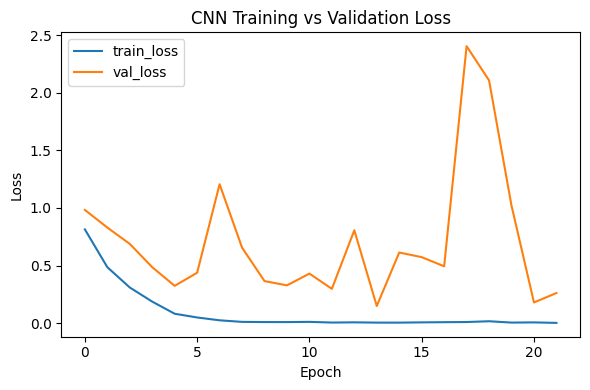

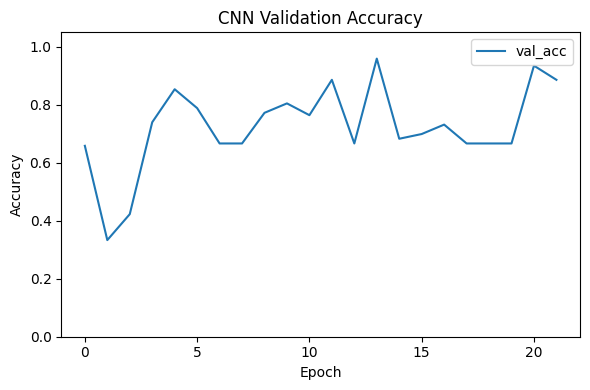

In [79]:
class Fan1DCNN(nn.Module):
    def __init__(self, n_classes: int, in_channels: int = 3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def make_loader(x_np, y_np, batch_size, shuffle):
    dataset = TensorDataset(torch.from_numpy(x_np).float(), torch.from_numpy(y_np).long())
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def train_cnn_classifier(
    x_train,
    y_train,
    x_val,
    y_val,
    *,
    label_to_idx,
    idx_to_label,
    save_path,
):
    train_loader = make_loader(x_train, y_train, CNN_BATCH_SIZE, shuffle=True)
    val_loader = make_loader(x_val, y_val, CNN_BATCH_SIZE, shuffle=False)

    model = Fan1DCNN(n_classes=len(label_to_idx)).to(DEVICE)
    counts = np.bincount(y_train, minlength=len(label_to_idx)).astype(np.float32)
    class_weights = counts.sum() / np.maximum(counts * len(label_to_idx), 1.0)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    @torch.no_grad()
    def evaluate(loader):
        model.eval()
        total_loss = 0.0
        all_true = []
        all_pred = []
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * yb.size(0)
            preds = torch.argmax(logits, dim=1)
            all_true.append(yb.cpu().numpy())
            all_pred.append(preds.cpu().numpy())

        y_true = np.concatenate(all_true)
        y_pred = np.concatenate(all_pred)
        avg_loss = total_loss / max(len(loader.dataset), 1)
        acc = accuracy_score(y_true, y_pred)
        return avg_loss, acc, y_true, y_pred

    def train_one_epoch(loader):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * yb.size(0)
        return total_loss / max(len(loader.dataset), 1)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_state = None
    best_val_loss = float("inf")
    wait = 0

    for epoch in range(1, CNN_EPOCHS + 1):
        train_loss = train_one_epoch(train_loader)
        val_loss, val_acc, _, _ = evaluate(val_loader)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"cnn epoch={epoch:02d} train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} lr={lr_now:.2e}"
        )

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= CNN_EARLY_STOP_PATIENCE:
                print("Early stopping triggered.")
                break

    if best_state is None:
        raise RuntimeError("Training did not produce a valid CNN state.")

    model.load_state_dict(best_state)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "label_to_idx": label_to_idx,
            "idx_to_label": idx_to_label,
            "mean": mean.astype(np.float32),
            "std": std.astype(np.float32),
            "window_len": int(target_len),
        },
        save_path,
    )
    print(f"Saved best 1D CNN to {save_path}")

    return {
        "model": model,
        "history": history,
        "label_to_idx": label_to_idx,
        "idx_to_label": idx_to_label,
        "save_path": save_path,
    }


@torch.no_grad()
def predict_cnn(bundle, x_np, batch_size=256):
    model = bundle["model"]
    model.eval()
    preds = []
    for start in range(0, len(x_np), batch_size):
        xb = torch.from_numpy(x_np[start:start + batch_size]).float().to(DEVICE)
        logits = model(xb)
        pred_idx = torch.argmax(logits, dim=1).cpu().numpy()
        preds.append(pred_idx)
    pred_idx = np.concatenate(preds)
    return np.array([bundle["idx_to_label"][int(idx)] for idx in pred_idx], dtype=np.int64)


cnn_bundle = train_cnn_classifier(
    X_train_classifier,
    y_train_classifier,
    X_val_known,
    y_val_classifier,
    label_to_idx=classifier_label_to_idx,
    idx_to_label=classifier_idx_to_label,
    save_path=ROOT / "experiment" / "weights" / "end_to_end_cnn1d.pt",
)

plt.figure(figsize=(6, 4))
plt.plot(cnn_bundle["history"]["train_loss"], label="train_loss")
plt.plot(cnn_bundle["history"]["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(cnn_bundle["history"]["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("CNN Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()
        

Known-class test accuracy: 0.976

              precision    recall  f1-score   support

      NORMAL       1.00      0.93      0.96        41
     BLOCKED       0.93      1.00      0.96        41
   INTERFERE       1.00      1.00      1.00        41

    accuracy                           0.98       123
   macro avg       0.98      0.98      0.98       123
weighted avg       0.98      0.98      0.98       123



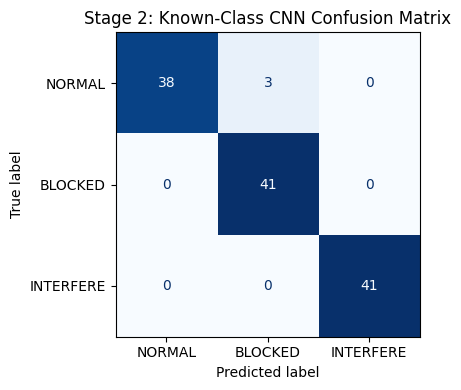

array([[38,  3,  0],
       [ 0, 41,  0],
       [ 0,  0, 41]])

In [80]:
y_known_test_pred = predict_cnn(cnn_bundle, X_known_test)

print(f"Known-class test accuracy: {accuracy_score(y_known_test_raw, y_known_test_pred):.3f}")
print()
print(classification_report(
    y_known_test_raw,
    y_known_test_pred,
    labels=known_labels,
    target_names=[LABEL_TO_NAME[label] for label in known_labels],
    zero_division=0,
))
plot_confusion(
    y_known_test_raw,
    y_known_test_pred,
    labels=known_labels,
    display_labels=[LABEL_TO_NAME[label] for label in known_labels],
    title="Stage 2: Known-Class CNN Confusion Matrix",
    figsize=(4.8, 4.0),
)
        

## Evaluation

Run the full cascade on the held-out test split. Stage 1 decides whether a sample is unknown. Only samples kept as known are allowed through to the CNN classifier.
        

 combined_accuracy  num_known_test_windows  num_unknown_test_windows  predicted_unknown_windows
          0.719512                     123                        41                         84

              precision    recall  f1-score   support

      NORMAL       1.00      0.90      0.95        41
     BLOCKED       0.93      0.98      0.95        41
   INTERFERE       0.00      0.00      0.00        41
     UNKNOWN       0.49      1.00      0.66        41

    accuracy                           0.72       164
   macro avg       0.60      0.72      0.64       164
weighted avg       0.60      0.72      0.64       164



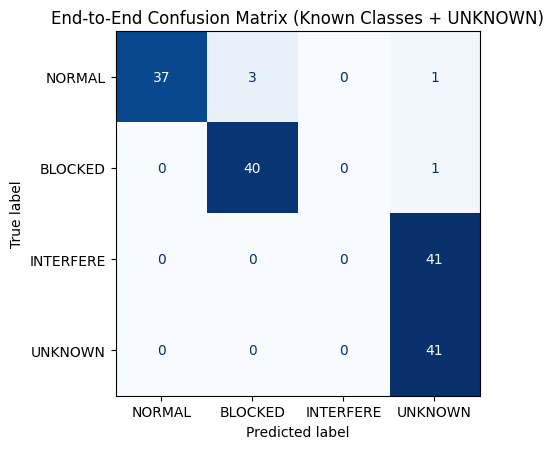

array([[37,  3,  0,  1],
       [ 0, 40,  0,  1],
       [ 0,  0,  0, 41],
       [ 0,  0,  0, 41]])

In [81]:
y_full_classifier_pred = predict_cnn(cnn_bundle, X_full_test)
y_combined_pred = np.where(y_stage1_pred == 1, UNKNOWN_LABEL, y_full_classifier_pred)

combined_labels = known_labels + [UNKNOWN_LABEL]
combined_summary = pd.DataFrame([
    {
        "combined_accuracy": accuracy_score(y_full_test_raw, y_combined_pred),
        "num_known_test_windows": int(np.sum(y_full_test_raw != UNKNOWN_LABEL)),
        "num_unknown_test_windows": int(np.sum(y_full_test_raw == UNKNOWN_LABEL)),
        "predicted_unknown_windows": int(np.sum(y_combined_pred == UNKNOWN_LABEL)),
    }
])
print(combined_summary.to_string(index=False))
print()
print(classification_report(
    y_full_test_raw,
    y_combined_pred,
    labels=combined_labels,
    target_names=[LABEL_TO_NAME[label] for label in combined_labels],
    zero_division=0,
))
plot_confusion(
    y_full_test_raw,
    y_combined_pred,
    labels=combined_labels,
    display_labels=[LABEL_TO_NAME[label] for label in combined_labels],
    title="End-to-End Confusion Matrix (Known Classes + UNKNOWN)",
    figsize=(5.6, 4.6),
)
        